STEP 1 — Install RDKit in Colab

In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 51.4 MB/s eta 0:00:00


STEP 2 — Load One Dataset (Example: Alanine)

In [ ]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Draw
import matplotlib.pyplot as plt

DATA_PATH = "/content/drive/MyDrive/Project/WS22Dataset/7032334/ws22_alanine.npz"
data = np.load(DATA_PATH, allow_pickle=True)

Z = data["Z"]
R = data["R"]
E = data["E"].flatten()

print("Total conformations:", len(E))

Total conformations: 120000


STEP 3 — Convert One Conformation to RDKit Molecule

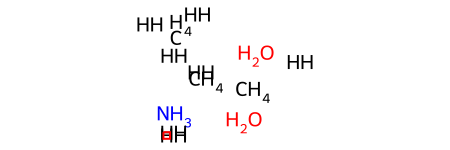

In [ ]:
from rdkit.Chem import rdchem

def build_rdkit_mol(Z, R):
    mol = Chem.RWMol()
    conf = Chem.Conformer(len(Z))

    for i, atomic_num in enumerate(Z):
        atom = Chem.Atom(int(atomic_num))
        mol_idx = mol.AddAtom(atom)
        x, y, z = R[i]
        conf.SetAtomPosition(mol_idx, (float(x), float(y), float(z)))

    mol.AddConformer(conf)
    return mol

mol = build_rdkit_mol(Z, R[0])
mol

STEP 4 — Infer Bonds Automatically

In [ ]:
from rdkit import Chem
from rdkit.Chem import rdchem
from rdkit.Chem import rdmolops
import numpy as np

# Covalent radii (simplified)
COVALENT_RADII = {
    1: 0.31,   # H
    6: 0.76,   # C
    7: 0.71,   # N
    8: 0.66    # O
}

def build_molecule_with_bonds(Z, R, scale=1.2):
    mol = Chem.RWMol()
    conf = Chem.Conformer(len(Z))

    for i, atomic_num in enumerate(Z):
        atom = Chem.Atom(int(atomic_num))
        mol_idx = mol.AddAtom(atom)
        conf.SetAtomPosition(mol_idx, tuple(R[i]))

    mol.AddConformer(conf)

    # Distance-based bond detection
    for i in range(len(Z)):
        for j in range(i+1, len(Z)):
            ri = COVALENT_RADII[int(Z[i])]
            rj = COVALENT_RADII[int(Z[j])]
            threshold = scale * (ri + rj)

            dist = np.linalg.norm(R[i] - R[j])

            if dist < threshold:
                mol.AddBond(i, j, rdchem.BondType.SINGLE)

    mol = mol.GetMol()
    Chem.SanitizeMol(mol)

    return mol

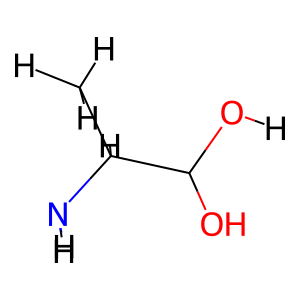

In [ ]:
mol = build_molecule_with_bonds(Z, R[0])
Chem.Draw.MolToImage(mol)

In [ ]:
mol = build_molecule_with_bonds(Z, R[0])

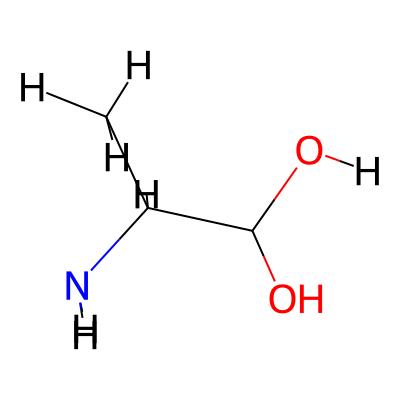

In [ ]:
from rdkit.Chem import Draw

img = Draw.MolToImage(mol, size=(400,400))
img

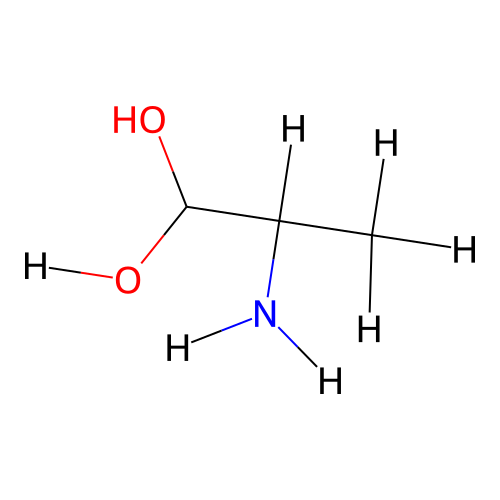

In [ ]:
from rdkit.Chem import AllChem

mol2d = Chem.Mol(mol)
AllChem.Compute2DCoords(mol2d)

Draw.MolToImage(mol2d, size=(500,500))

In [ ]:
!pip install py3Dmol

In [ ]:
import py3Dmol
from rdkit.Chem import AllChem

mol3d = build_molecule_with_bonds(Z, R[0])

mb = Chem.MolToMolBlock(mol3d)

view = py3Dmol.view(width=500, height=500)
view.addModel(mb, 'mol')
view.setStyle({'stick':{}})
view.setBackgroundColor('white')
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Visualize Multiple Conformations

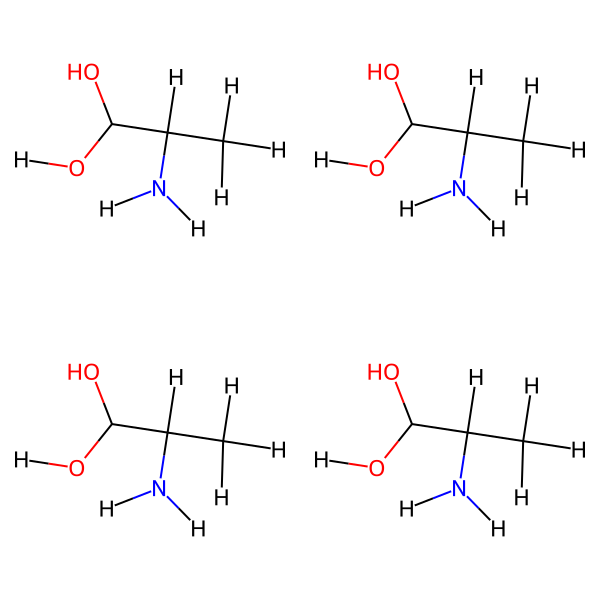

In [ ]:
from rdkit.Chem import Draw

mols = []
for i in range(4):
    mol_i = build_molecule_with_bonds(Z, R[i])
    AllChem.Compute2DCoords(mol_i)
    mols.append(mol_i)

Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(300,300))